In [1]:
# Limpar ambiente (não necessário em Python como em R)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# rpy2 para rodar NbClust do R
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [2]:
# -------------------------
# Gerar dados simulados
# -------------------------
np.random.seed(10)

num_clientes = 500

consumo_laticinios = np.abs(np.random.normal(loc=50, scale=30, size=num_clientes))
consumo_carne = np.abs(np.random.normal(loc=70, scale=40, size=num_clientes))
consumo_padaria = np.abs(np.random.normal(loc=30, scale=10, size=num_clientes))

dados = pd.DataFrame({
    "laticinios": consumo_laticinios,
    "carne": consumo_carne,
    "padaria": consumo_padaria
})

print(dados.head())

   laticinios       carne    padaria
0   89.947595  127.570149  45.132522
1   71.458369  125.285865  28.576664
2    3.637991  106.852817  28.605800
3   49.748485   47.084511  41.755075
4   68.640079  121.001964  41.837890


In [3]:
# -------------------------
# Padronizar dados
# -------------------------
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(dados)

In [4]:
# -------------------------
# NbClust (via R)
# -------------------------
utils = importr("utils")

try:
    nbclust = importr("NbClust")
except:
    utils.install_packages("NbClust")
    nbclust = importr("NbClust")

dados_padronizados_df = pd.DataFrame(
    dados_padronizados,
    columns=dados.columns
)

In [5]:
# converter Python -> R
with localconverter(ro.default_converter + pandas2ri.converter):
    r_dados = ro.conversion.py2rpy(dados_padronizados_df)


In [6]:
# rodar NbClust
resultado = nbclust.NbClust(
    r_dados,
    distance="euclidean",
    min_nc=3,
    max_nc=10,
    method="kmeans"
)

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 
*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 5 proposed 3 as the best number of clusters 
* 11 proposed 4 as the best number of clusters 
* 1 proposed 5 as the best number of clusters 
* 3 proposed 8 as the best number of clusters 
* 3 proposed 10 as the best numbe

In [7]:
# votos dos índices
best_nc = np.array(resultado.rx2("Best.nc"))
k_votes = best_nc[0]

freq = pd.Series(k_votes).value_counts().sort_index()

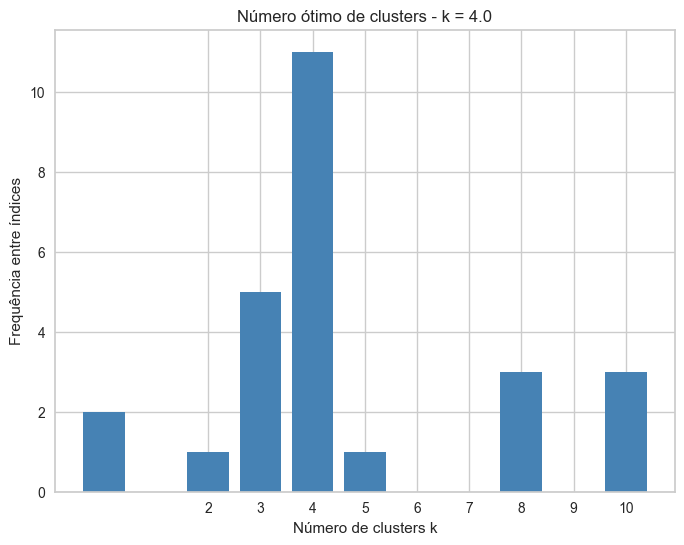

Número ótimo de clusters segundo NbClust: 4


In [20]:
# gráfico NbClust
plt.figure(figsize=(8,6))
plt.bar(freq.index, freq.values, color="steelblue")

plt.xlabel("Número de clusters k")
plt.ylabel("Frequência entre índices")
plt.title(f"Número ótimo de clusters - k = {freq.idxmax()}")

plt.xticks(range(2,11))
plt.show()

# k ideal segundo NbClust
k_ideal = int(freq.idxmax())

print(f"Número ótimo de clusters segundo NbClust: {k_ideal}")

In [16]:
# -------------------------
# Aplicar KMeans
# -------------------------
kmeans = KMeans(n_clusters=k_ideal, n_init=20, random_state=10)
clusters = kmeans.fit_predict(dados_padronizados)

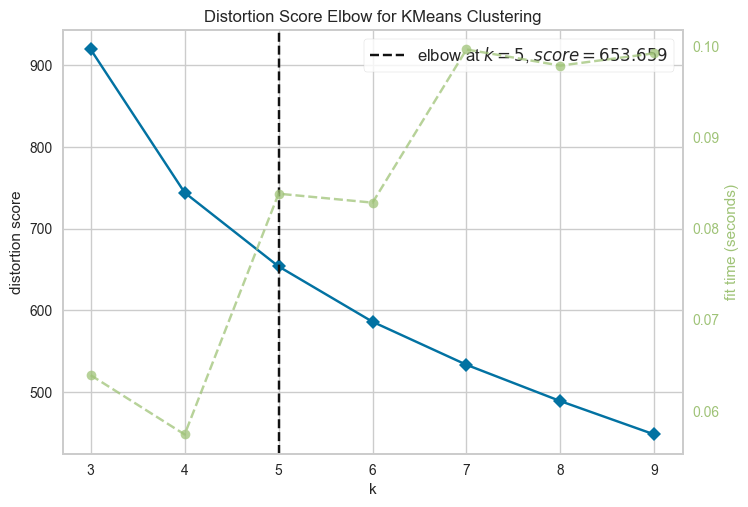

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
# -------------------------
# Visualizar clusters
# -------------------------

visualizer = KElbowVisualizer(kmeans, k=range(3, 10), force_model=True)

visualizer.fit(dados_padronizados)
visualizer.show()


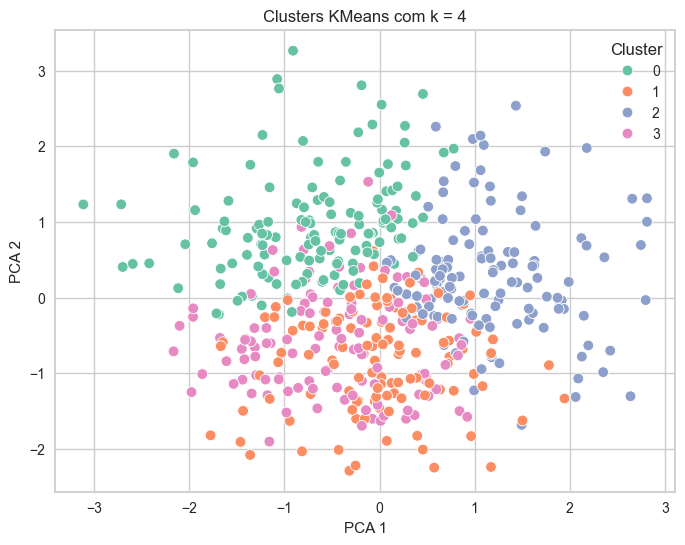

In [11]:
# -------------------------
# Visualizar clusters com PCA (2D)
# -------------------------
pca = PCA(n_components=2)
dados_pca = pca.fit_transform(dados_padronizados)

plt.figure(figsize=(8,6))
sns.scatterplot(x=dados_pca[:,0], y=dados_pca[:,1], hue=clusters, palette='Set2', s=60)
plt.title(f"Clusters KMeans com k = {k_ideal}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster')
plt.show()

In [12]:
silhouette_avg = silhouette_score(dados_padronizados, clusters)
print("Silhouette média:", silhouette_avg)

Silhouette média: 0.2421637431854324


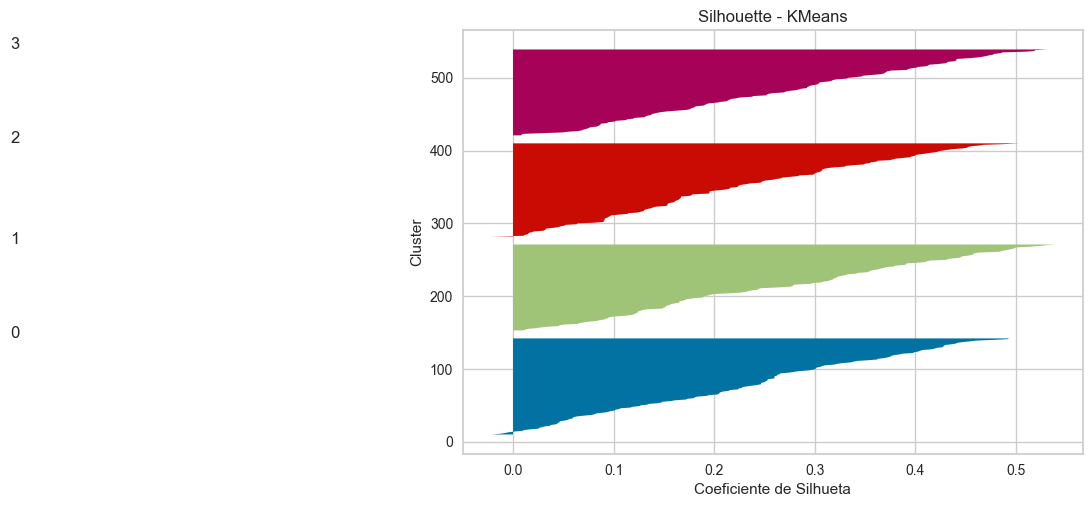

In [21]:
# -------------------------
# Silhouette
# -------------------------

silhouette_vals = silhouette_samples(dados_padronizados, clusters)

y_lower = 10

for i in range(k_ideal):
    cluster_vals = silhouette_vals[clusters == i]
    cluster_vals.sort()
    
    size_cluster = cluster_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_vals)
    
    plt.text(-0.05, y_lower +   0.5 * size_cluster, str(i))
    y_lower = y_upper + 10

# Plot silhouette
plt.title("Silhouette - KMeans")
plt.xlabel("Coeficiente de Silhueta")
plt.ylabel("Cluster")
plt.show()

In [14]:
# -------------------------
# Tamanho dos clusters
# -------------------------

unique, counts = np.unique(clusters, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

print("Tamanho dos clusters:")
print(cluster_sizes)

Tamanho dos clusters:
{np.int32(0): np.int64(133), np.int32(1): np.int64(119), np.int32(2): np.int64(129), np.int32(3): np.int64(119)}
